## Notebook Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install torchray captum lime -q
!pip install torch torchvision captum quantus seaborn -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 28.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install shap -q
!pip install hydra-core -q
!pip install fedlab -q
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import copy
import statistics
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import yaml
import os
from fedlab.utils.dataset.partition import  BasicPartitioner
from torch.utils.data import Subset
import matplotlib.pyplot as plt
from collections import OrderedDict
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor, as_completed
import shap
import hydra
from hydra.core.hydra_config import HydraConfig
from omegaconf import DictConfig, OmegaConf
import random
import numpy as np
import torch
# Set seed for Python's random module
random.seed(42)
# Set seed for NumPy
np.random.seed(42)
# Set seed for PyTorch
torch.manual_seed(42)
import numpy as np
import torch
import torch.nn.functional as F
import random
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import os
import seaborn as sns
# If you are using CUDA, you may also want to set the seed for GPU operations
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # For all GPUs if you have multiple


import pathlib
import numpy as np
import pandas as pd
import quantus
from captum.attr import IntegratedGradients
import torch
import torch.nn as nn
torch.manual_seed(27)
#clear_output()
np.random.seed(27)



- num_rounds: 5 # number of FL rounds in the experiment
- num_clients: 30 # number of total clients
- num_edges: 5

config_fit: # a config that each client will receive. This is sent by the server. This will dynamically configure the training on the client side as the simulation progresses.
- lr: 0.01 # learning rate to used by the clients
- momentum: 0.9 # momentum used by SGD optimiser on the client side
- local_epochs: 10 # training epochs each client executes in a fit() round
- batch_size: 64 # batch size to use by clients during training

#### 1. Load and preprocess the dataset. Get Training and test dataset

In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_flag_distribution(df, class_labels=None):
    """
    Plots the distribution of the 'flag' column in the dataset.

    Parameters:
        df (pd.DataFrame): The dataframe containing the 'flag' column.
        class_labels (dict, optional): A dictionary to map flag values to meaningful class names.
                                       Example: {"R": "Normal", "T": "Attack"}.
    """
    sns.countplot(x="label", data=df, palette="viridis", hue="label", legend=False)
    plt.title("Flag Value Counts")
    if class_labels:
        plt.xticks(
            ticks=range(len(class_labels)),
            labels=[class_labels[label] for label in class_labels]
        )
    plt.show()

def preprocess_dataset():
    processed_file = "/content/drive/MyDrive/car_hacking_dataset/Dataset/Car_Hacking_preprocessed_dataset.csv"
    class_labels = {"R": "Normal", "T": "Attack"}

    # Load processed dataset if it exists
    if os.path.isfile(processed_file):
        df = pd.read_csv(processed_file)
        if "flag" in df.columns and "label" not in df.columns:
            df.rename(columns={"flag": "label"}, inplace=True)
        plot_flag_distribution(df, class_labels)
        return df

    # Raw data file paths
    raw_files = {
        "normal": "/content/drive/MyDrive/Normal_data.csv",
        "dos": "/content/drive/MyDrive/DoS_dataset.csv",
        "fuzzy": "/content/drive/MyDrive/Fuzzy_dataset.csv",
        "gear": "/content/drive/MyDrive/gear_dataset.csv",
        "rpm": "/content/drive/MyDrive/RPM_dataset.csv"
    }

    column_names = ["Timestamp", "ID", "DLC", "Byte1", "Byte2", "Byte3", "Byte4", "Byte5", "Byte6", "Byte7", "Byte8", "flag"]
    dataframes = []

    # Load and process raw files
    for key, path in raw_files.items():
        df = pd.read_csv(path, names=column_names, index_col=False) if key != "normal" else pd.read_csv(path, index_col=False)
        if key == "normal":
            df["flag"] = "R"  # Assign flag for normal data
        dataframes.append(df)

    # Combine all datasets
    df = pd.concat(dataframes, axis=0, ignore_index=True)
    print(f"Total data shape before removing missing data: {df.shape}")

    # Drop rows with missing data
    df.dropna(inplace=True)
    print(f"Total data shape after removing missing data: {df.shape}")

    # Convert Hexadecimal Byte columns to Decimal and drop original Byte columns
    byte_columns = [f"Byte{i}" for i in range(1, 9)]
    for i, byte_col in enumerate(byte_columns):
        df[f"DATA_{i}"] = df[byte_col].apply(lambda x: int(str(x), 16))
    df.drop(columns=byte_columns, inplace=True)

    # Drop unnecessary columns
    df.drop(columns=["Timestamp", "ID", "DLC"], inplace=True)

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f"Data shape after removing duplicate entries: {df.shape}")

    # Save the processed dataset
    os.makedirs(os.path.dirname(processed_file), exist_ok=True)
    df.to_csv(processed_file, index=False)

    # Visualize and rename flag column
    plot_flag_distribution(df, class_labels)
    if "flag" in df.columns and "label" not in df.columns:
        df.rename(columns={"flag": "label"}, inplace=True)

    return df

In [7]:
def prepare_training_testing_data(dataset, test_size=0.30, output_dir="/content/drive/MyDrive/car_hacking_dataset/Dataset"):
    """
    Prepares and pre-processes the dataset for training and testing.

    This function shuffles the dataset, encodes labels, scales features, and splits the data
    into training and testing sets. It also saves the processed training and testing data into CSV files.

    Args:
        dataset (pd.DataFrame): The input dataset containing features and labels.
        test_size (float, optional): Proportion of the dataset to be used for testing. Defaults to 0.30.
        output_dir (str, optional): Directory where processed files will be saved. Defaults to a specified path.

    Returns:
        tuple:
            X_train_scaled (numpy.ndarray): Scaled feature matrix for the training set.
            X_test_scaled (numpy.ndarray): Scaled feature matrix for the test set.
    """
    # Shuffle the dataset
    dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

    # Encode labels
    label_mapping = {"R": 0, "T": 1}
    dataset['label'] = dataset['label'].map(label_mapping)

    # Split into train and test sets
    train_df, test_df = train_test_split(dataset, test_size=test_size, stratify=dataset['label'], random_state=42)

    # Split features and labels
    X_train, y_train = train_df.drop(columns=['label']), train_df['label']
    X_test, y_test = test_df.drop(columns=['label']), test_df['label']

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Prepare scaled datasets for saving
    train_df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    train_df_scaled['label'] = y_train.values

    test_df_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    test_df_scaled['label'] = y_test.values

    # Save processed datasets
    os.makedirs(output_dir, exist_ok=True)
    train_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_trainset.csv"), index=False)
    test_df_scaled.to_csv(os.path.join(output_dir, "car_hacking_testset.csv"), index=False)

    return X_train_scaled, X_test_scaled

def get_car_hacking_dataset():
    """
    Loads and prepares the CiCiov dataset for training and testing in PyTorch format.

    This function reads the pre-processed train and test CSV files, converts the data into PyTorch tensors,
    and creates TensorDataset objects for both the training and testing data. It also returns the target labels
    separately for both the train and test sets.

    Args:
        None

    Returns:
        tuple:
            train_tensor (torch.utils.data.TensorDataset): Tensor dataset containing training features and labels.
            test_tensor (torch.utils.data.TensorDataset): Tensor dataset containing test features and labels.
            train_target (torch.Tensor): Tensor containing training labels.
            test_target (torch.Tensor): Tensor containing test labels.
    """
    train = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_trainset.csv')
    test = pd.read_csv('/content/drive/MyDrive/car_hacking_dataset/Dataset/car_hacking_testset.csv')
    train_target = torch.tensor(train['label'].values.astype(np.float32))
    train = torch.tensor(train.drop('label', axis = 1).values.astype(np.float32))
    train_tensor = TensorDataset(train, train_target)

    test_target = torch.tensor(test['label'].values.astype(np.float32))
    test = torch.tensor(test.drop('label', axis = 1).values.astype(np.float32))
    test_tensor = TensorDataset(test, test_target)

    return train_tensor , test_tensor ,train_target,test_target

#### 2. Split the Training set into M parts with M-Number of Clients. Here the test set will not be split. It will be used to test the Global Model.

In [8]:
import torch
from torch.utils.data import DataLoader, Subset

def get_all_labels(dataset):
    """
    Extract all labels from the given dataset.

    Args:
        dataset (Iterable): The dataset from which to extract labels.
                            It should yield pairs of (data, labels).

    Returns:
        torch.Tensor: A tensor containing all the labels stacked together.
    """
    all_labels = []

    # Iterate through the dataset to collect all labels
    for _, labels in dataset:
        all_labels.append(labels)

    # Stack all labels into a single tensor
    all_labels_tensor = torch.stack(all_labels)

    return all_labels_tensor

def split_dataset(train_set, test_set, num_clients, batch_size, partition, dir_alpha=None, major_classes_num=0):
    """
    Split the dataset into multiple clients for federated learning.

    Args:
        train_set (Dataset): The training dataset to be partitioned.
        test_set (Dataset): The testing dataset.
        num_clients (int): The number of clients to split the data among.
        batch_size (int): The batch size for the data loaders.
        partition (str): The type of partitioning ('iid' for independent and identically distributed).
        dir_alpha (float, optional): Dirichlet parameter for non-iid partitioning.
        major_classes_num (int, optional): Number of major classes for partitioning.

    Returns:
        list: A list of DataLoaders for the training sets of each client.
        DataLoader: A DataLoader for the test set.
    """

    # Initialize the partitioner with the labels from the training set
    partitioner = BasicPartitioner(
        get_all_labels(train_set),
        num_clients,
        partition=partition,
        dir_alpha=dir_alpha,
        major_classes_num=major_classes_num,
        seed=2023
    )

    trainloaders = []

    # Create a DataLoader for each client's training set
    for client in range(num_clients):
        idx = partitioner.client_dict[client]  # Get indices for the current client
        trainset_ = Subset(train_set, idx)  # Create a subset for the client

        # Create a DataLoader for the client's training set
        trainloaders.append(DataLoader(trainset_, batch_size=batch_size, shuffle=True))

    # Create a DataLoader for the test set (no shuffling)
    testloader = DataLoader(test_set, batch_size=batch_size)
    # Create a DataLoader for the Training data to get training loss
    raw_train_loader = DataLoader(train_set, batch_size=batch_size)
    return raw_train_loader ,trainloaders, testloader


#### 3.Model Architecture

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time


class ANNModel(nn.Module):
    def __init__(self, input_features=8):
        super(ANNModel, self).__init__()
        # Define an abbreviation for the model
        self.abbrv = "ann"  # or any suitable identifier

        # Fully connected layers for a simple ANN
        self.fc1 = nn.Linear(input_features, 16)  # First hidden layer with 64 neurons
        self.fc2 = nn.Linear(16, 8)  # Second hidden layer with 32 neurons
        self.fc3 = nn.Linear(8, 1)  # Output layer for binary classification

        # Dropout layer to reduce overfitting
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Forward pass through fully connected layers with ReLU and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


def train(net, trainloader, optimizer, epochs):
    """
    Train a neural network model using a specified optimizer and dataset.
    """
    criterion = nn.BCEWithLogitsLoss()
    net.train()
    start_time = time.time()  # Start time for the training

    for _ in range(epochs):
        for features, labels in trainloader:
            optimizer.zero_grad()
            output = net(features)
            loss = criterion(output.squeeze(1), labels.float())
            loss.backward()
            optimizer.step()

        time.sleep(1)  # Simulate some delay

    end_time = time.time()  # End time for the training
    total_time = end_time - start_time
    return total_time


def evaluate_model(model, test_loader):
    """
    Evaluate a trained neural network model on a test dataset.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, labels in test_loader:
            outputs = model(data)
            outputs = outputs.squeeze(1)
            loss = F.binary_cross_entropy_with_logits(outputs, labels.float())

            total_loss += loss.item() * data.size(0)
            preds = torch.round(torch.sigmoid(outputs))
            total_correct += (preds == labels).sum().item()
            total_samples += data.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, conf_matrix


# Function to load the model
def load_model(model_path, input_features=8, device="cpu"):
    # Initialize the model
    model = ANNModel(input_features)
    #model.load_state_dict(torch.load(model_path, map_location=device,weights_only=True))
    model.load_state_dict(torch.load(model_path, map_location=device))

    model.to(device)  # Move model to the specified device
    model.eval()  # Set to evaluation mode
    print(f"Model loaded from {model_path}")
    return model

#### Get Training and Test Dataset

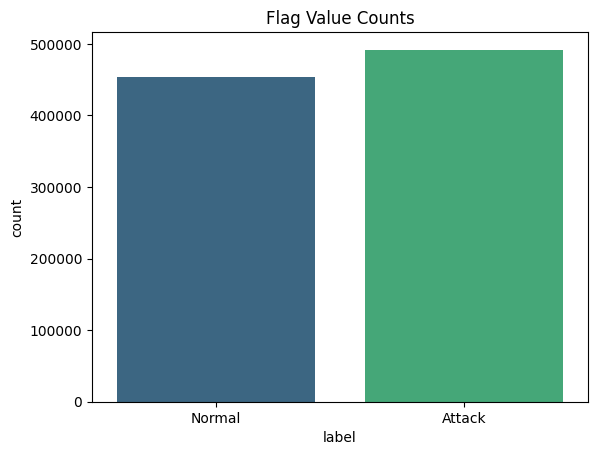

<ipython-input-10-c9da911fbc2f>:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_target_tensor = torch.tensor(test_target, dtype=torch.long)  # Ensure target is long for classification


In [10]:
#  Preprocess the Dataset
df = preprocess_dataset()

# Pre-process the dataset by splitting it into training and testing sets
# The parameter test_size=0.3 indicates that 30% of the data will be used for testing
x_train, x_test = prepare_training_testing_data(df,test_size=0.3)

# Convert the training data (x_train) into a PyTorch tensor of type float32
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)

# Convert the testing data (x_test) into a PyTorch tensor of type float32
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)


# Load the dataset for a specific application (Car-Hacking dataset)
# The function returns training and testing datasets, as well as their corresponding targets
trainset, testset, train_target, test_target = get_car_hacking_dataset()##

test_target_tensor = torch.tensor(test_target, dtype=torch.long)  # Ensure target is long for classification

# Create a proper dataset
testset = TensorDataset(X_test_tensor, test_target_tensor)

with open('/content/drive/MyDrive/base.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

## Get Trainloaders and Testloader
raw_train_loader,trainloaders, testloader = split_dataset(trainset, testset, cfg['num_clients'], cfg['config_fit']['batch_size'], partition='noniid-labeldir', dir_alpha=1)


## Load The model and Custom path

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
#inputs, labels = next(iter(testloader))
#labels = labels.type(torch.int64)

# Example usage
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("The device is ",device)

The device is  cuda


In [13]:
samples_to_train=2000
samples_to_test=500
#model = load_model(model_path, input_features=8, device=device)
method_name="AFL1"
# Custom Path to save the plots
path = f"/content/drive/MyDrive/{method_name}/lime_vs_shap_comparison_results"
os.makedirs(path, exist_ok=True)

# Load federated model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model("/content/drive/MyDrive/car_hacking_results/AFL1_Exp1_09_02_2025/model_checkpoint/AFL1/model_AFL1_round_5.pth",
                   input_features=8, device=device)

<ipython-input-9-48090a6f1da6>:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


Model loaded from /content/drive/MyDrive/car_hacking_results/AFL1_Exp1_09_02_2025/model_checkpoint/AFL1/model_AFL1_round_5.pth


In [14]:
from IPython.display import clear_output
import pathlib
import numpy as np
import pandas as pd
import quantus
import torch
import torchvision
from captum.attr import *
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Enable GPU.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
clear_output()

## Explanations and Metrics for Shap

In [15]:
def shap_method(model, inputs, targets=None, **kwargs):
    """
    Generates SHAP (SHapley Additive exPlanations) summary plot for a given model and saves the results.

    This function computes SHAP values for a given trained model and test data using the DeepExplainer,
    creates a summary plot for feature importance, and saves the plot to a specified directory.

    Args:
        model (torch.nn.Module): The trained PyTorch model to be explained.
        method_name (str): The name of the method, used for naming and organizing output files.
        x_train (torch.Tensor): The training data tensor, used by the SHAP explainer to compute expected outputs.
        x_test (torch.Tensor): The test data tensor, used to compute SHAP values and generate the summary plot.

    Returns:
        None: The function saves the SHAP summary plot to the specified directory and prints the path to the saved plot.

    Side Effects:
        - Saves a SHAP summary plot as a PNG image in the specified directory.
        - Displays the SHAP plot inline (if running in an environment that supports plotting).
    """

    model.eval()
    x_train=kwargs.get("x_train")
    if isinstance(x_train, np.ndarray):
        x_train = torch.tensor(x_train, dtype=torch.float32)
    x_train=x_train.to(device)
    # Create the SHAP explainer
    explainer = shap.DeepExplainer(model,x_train)

    # Calculate SHAP values
    shap_values = explainer.shap_values(inputs, check_additivity=False)
    # Reshape SHAP values if needed
    shap_values_reshaped = shap_values.squeeze()
    if isinstance(shap_values_reshaped, torch.Tensor):
        shap_values_reshaped = shap_values_reshaped.detach().cpu().numpy()
    return shap_values_reshaped




In [16]:
# Prepare data
x_train = X_train_tensor[:samples_to_train].to(device)
x_test = X_test_tensor[:samples_to_test].to(device)
y_test=test_target.detach().cpu().numpy()[:samples_to_test]

shap_values = shap_method(model,x_test,targets=y_test,x_train=x_train)

In [17]:
y_train=train_target.detach().cpu().numpy()[:samples_to_train]
y_train.shape,y_test.shape,shap_values.shape

((2000,), (500,), (500, 8))

### MPRT Score

In [18]:
quantus.MPRT().get_params

{'abs': True,
 'normalise': True,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x7f9c7dd05db0>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Optional[Sequence[int]] = None) -> numpy.ndarray>,
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None,
 'similarity_func': <function quantus.functions.similarity_func.correlation_spearman(a: <built-in function array>, b: <built-in function array>, **kwargs) -> float>,
 'layer_order': 'top_down',
 'seed': 42,
 'return_average_correlation': False,
 'return_last_correlation': False,
 'skip_layers': False}

In [19]:
metric = quantus.MPRT(
    similarity_func=quantus.similarity_func.correlation_spearman,
    return_average_correlation=True,
    return_aggregate=True,
    aggregate_func=np.mean,
    layer_order="independent",
    disable_warnings=True,
    normalise=True,
    abs=True,
    display_progressbar=True
)

shap_mprt = metric(
    model=model,
    x_batch=x_test.to(device),
    y_batch=y_test,
    a_batch=shap_values,
    explain_func=shap_method,
    explain_func_kwargs={"x_train": x_train.to(device)}  # Ensure "x_test" is passed
)


  0%|          | 0/1500 [00:00<?, ?it/s]

In [20]:
shap_mprt[0].round(3)

0.529

### Complexity

In [21]:
quantus.Complexity().get_params

{'abs': True,
 'normalise': True,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x7f9c7dd05db0>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Optional[Sequence[int]] = None) -> numpy.ndarray>,
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None}

In [22]:
shap_complexity = quantus.Complexity(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True
)(
    model=model,
    x_batch=x_test,
    y_batch=y_test,
    a_batch=shap_values,
    explain_func=shap_method,
    explain_func_kwargs={"x_train": x_train}  # Ensure "x_test" is passed
)


print(
    f"Complexity Bhatt et al., 2020.\n"
    f"\n • SHAP = ",
   shap_complexity,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

Complexity Bhatt et al., 2020.

 • SHAP =  [1.728057599973211]


In [23]:
shap_complexity[0].round(3)

1.728

### Sparsness

In [24]:
shap_Sparseness = quantus.Sparseness(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True,
)(
    model=model,
    x_batch=x_test,
    y_batch=y_test,
    a_batch=None,
    explain_func=shap_method,
    explain_func_kwargs={"x_train": x_train}  # Ensure "x_test" is passed
)

print(
    f"Complexity Bhatt et al., 2020.\n"
    f"\n • SHAP = ",
   shap_Sparseness,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

Complexity Bhatt et al., 2020.

 • SHAP =  [0.43076612641203604]


In [25]:
shap_Sparseness[0].round(3)

0.431

### EffectiveComplexity

In [26]:
shap_EffectiveComplexity = quantus.EffectiveComplexity(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True,
)(
    model=model,
    x_batch=x_test,
    y_batch=y_test,
    a_batch=None,
    explain_func=shap_method,
    explain_func_kwargs={"x_train": x_train}  # Ensure "x_test" is passed
)

print(
    f"Complexity Bhatt et al., 2020.\n"
    f"\n • SHAP = ",
   shap_EffectiveComplexity,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

Complexity Bhatt et al., 2020.

 • SHAP =  [8.0]


## Explanations and Metrics for Lime

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

def lime_explanation_callable(model, inputs, targets,x_train_np):
    """
    Computes LIME explanations for the given input data.

    :param model: Trained PyTorch model.
    :param inputs: Input data batch (torch.FloatTensor).
    :param targets: Target labels (not used directly in LIME but included for API consistency).
    :param feature_names: List of feature names.
    :param x_train: Background dataset for LIME.
    :param num_samples: Number of samples for LIME perturbations.
    :param instance_idx: Index of instance to visualize.
    :param label: Class label to explain.
    :return: NumPy array of LIME attributions (same shape as inputs).
    """
    x_test=inputs

    num_samples=5000
    label=1
    feature_names = ["DATA_0", "DATA_1", "DATA_2", "DATA_3", "DATA_4", "DATA_5", "DATA_6", "DATA_7"]
    # Convert training data to numpy
    #x_train_np = inputs.cpu().numpy()
    explainer = LimeTabularExplainer(
        x_train_np.cpu().numpy(),
        feature_names=feature_names,
        class_names=['Normal', 'Attack'],
        discretize_continuous=True
    )

    def model_predict(input_data):
        """Predict function for LIME, returning probabilities."""
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32).to(device)
        model.eval()
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.sigmoid(output).cpu().numpy()
        return np.hstack([1 - probabilities, probabilities])

    #inputs_np = inputs.cpu().numpy()
    lime_importances = []

    for idx, sample in enumerate(x_test):
      if isinstance(sample, torch.Tensor):
        sample = sample.detach().cpu().numpy()
        exp = explainer.explain_instance(
            sample,
            model_predict,
            num_features=len(feature_names),
            num_samples=num_samples,
            labels=(label,)
        )
        lime_importances.append([exp.local_exp[label][i][1] for i in range(len(feature_names))])

        # Generate visualization for first instance
        # if idx == instance_idx:
        #     print(f"Generating LIME chart for instance {inputs[idx].cpu().numpy()}")
        #     fig = exp.as_pyplot_figure()
        #     plt.title(f"LIME Explanation for Instance {instance_idx}")
        #     plt.show()
        #     plt.close()

    return np.array(lime_importances)


In [28]:
lime_exps=lime_explanation_callable(model, inputs=x_test, targets=y_test,x_train_np=x_train)


In [29]:
lime_exps.shape,x_test.shape

((500, 8), torch.Size([500, 8]))

### MPRT Score

In [30]:
quantus.MPRT().get_params

{'abs': True,
 'normalise': True,
 'return_aggregate': False,
 'aggregate_func': <function mean at 0x7f9c7dd05db0>,
 'normalise_func': <function quantus.functions.normalise_func.normalise_by_max(a: numpy.ndarray, normalise_axes: Optional[Sequence[int]] = None) -> numpy.ndarray>,
 '_disable_warnings': False,
 '_display_progressbar': False,
 'a_axes': None,
 'similarity_func': <function quantus.functions.similarity_func.correlation_spearman(a: <built-in function array>, b: <built-in function array>, **kwargs) -> float>,
 'layer_order': 'top_down',
 'seed': 42,
 'return_average_correlation': False,
 'return_last_correlation': False,
 'skip_layers': False}

In [31]:
metric = quantus.MPRT(
    similarity_func=quantus.similarity_func.correlation_spearman,
    return_average_correlation=True,
    return_aggregate=True,
    aggregate_func=np.mean,
    layer_order="independent",
    disable_warnings=True,
    normalise=True,
    abs=True,
    display_progressbar=True
)

lime_mprt = metric(
    model=model,
    x_batch=x_test.to(device),
    y_batch=y_test,
    a_batch=lime_exps,
    explain_func=lime_explanation_callable,
    explain_func_kwargs={"x_train_np": x_train.to(device)}
)


  0%|          | 0/1500 [00:00<?, ?it/s]

In [32]:
lime_mprt[0].round(3)

1.0

### Complexity

In [33]:
lime_complexity = quantus.Complexity(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True
)(
    model=model,
    x_batch=x_test.to(device),
    y_batch=y_test,
    a_batch=lime_exps,
    explain_func=lime_explanation_callable,
    explain_func_kwargs={"x_train_np": x_train.to(device)}
)

print(
    f"Complexity Bhatt et al., 2020.\n"
    f"\n • LIME = ",
   lime_complexity,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

Complexity Bhatt et al., 2020.

 • LIME =  [1.759579483735629]


In [34]:
lime_complexity[0].round(3)

1.76

### Sparseness

In [35]:
lime_Sparseness = quantus.Sparseness(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True,
)(
    model=model,
    x_batch=x_test.to(device),
    y_batch=y_test,
    a_batch=lime_exps,
    explain_func=lime_explanation_callable,
    explain_func_kwargs={"x_train_np": x_train.to(device)}
)

print(
    f"Sparseness\n"
    f"\n • LIME = ",
    lime_Sparseness,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

Sparseness

 • LIME =  [0.41748689637050396]


In [36]:
lime_Sparseness[0].round(3)

0.417

### EffectiveComplexity

In [37]:
lime_EffectiveComplexity = quantus.EffectiveComplexity(
    normalise=True,
    abs=True,
    disable_warnings=True,
    display_progressbar=True,
    return_aggregate=True,
)(
    model=model,
    x_batch=x_test.to(device),
    y_batch=y_test,
    a_batch=lime_exps,
    explain_func=lime_explanation_callable,
    explain_func_kwargs={"x_train_np": x_train.to(device)}
)

print(
    f"EffectiveComplexity.\n"
    f"\n • LIME = ",
   lime_EffectiveComplexity,
)

  0%|          | 0/8.0 [00:00<?, ?it/s]

EffectiveComplexity.

 • LIME =  [8.0]


## Results Comparison of Quantus Metrics

In [38]:
shap_complexity

[1.728057599973211]

In [39]:
import pandas as pd

# Define metrics and their corresponding values
metrics = ["MPRT","Complexity", "Effective Complexity", "Sparseness"]
shap_scores = [shap_mprt[0].round(3),shap_complexity[0].round(3), shap_EffectiveComplexity[0].round(3), shap_Sparseness[0].round(3)]
lime_scores = [lime_mprt[0].round(3),lime_complexity[0].round(3), lime_EffectiveComplexity[0].round(3), lime_Sparseness[0].round(3)]

# Create a DataFrame
df = pd.DataFrame({"Metric": metrics, "SHAP": shap_scores, "LIME": lime_scores})

custom_path = os.path.join(path, "explanation_metrics.csv")

# Save the DataFrame as a CSV file
df.to_csv(custom_path, index=False)
df

,Metric,SHAP,LIME
0,MPRT,0.529,1.000
1,Complexity,1.728,1.760
2,Effective Complexity,8.000,8.000
3,Sparseness,0.431,0.417


# Open XAI Metrics

In [40]:
!pip install torchray captum lime -q


In [41]:
import sys
sys.path.append('/content/drive/MyDrive/OpenXAI-main/OpenXAI-main')

In [42]:
from openxai.evaluator import ground_truth_metrics, prediction_metrics, stability_metrics
from openxai.experiment_utils import print_summary, load_config, fill_param_dict
from openxai.explainers.perturbation_methods import get_perturb_method
import torch
import numpy as np
from openxai.experiment_utils import print_summary, load_config, fill_param_dict
from openxai.explainers.perturbation_methods import get_perturb_method
# ML models
from openxai.model import LoadModel
# Data loaders
from openxai.dataloader import ReturnLoaders, ReturnTrainTestX
# Explanation models
from openxai.explainer import Explainer
# Evaluation methods
from openxai.evaluator import Evaluator
print('Ground truth metrics: ', ground_truth_metrics)

Ground truth metrics:  ['PRA', 'RC', 'FA', 'RA', 'SA', 'SRA']


## Util Functions

#### Pertub method

In [43]:
class BasePerturbation:
    '''
    Base Class for perturbation methods.
    '''

    def __init__(self, data_format):
        '''
        Initialize generic parameters for the perturbation method
        '''
        self.data_format = data_format

    def get_perturbed_inputs(self):
        '''
        This function implements the logic of the perturbation methods which will return perturbed samples.
        '''
        pass


class NormalPerturbation(BasePerturbation):
    def __init__(self, data_format, mean: int = 0, std_dev: float = 0.05, flip_percentage: float = 0.3):
        self.mean = mean
        self.std_dev = std_dev
        self.flip_percentage = flip_percentage

        super(NormalPerturbation, self).__init__(data_format)
        '''
        Initializes the marginal perturbation method where each column is sampled from marginal distributions given per variable.
        dist_per_feature : vector of distribution generators (tdist under torch.distributions).
        Note : These distributions are assumed to have zero mean since they get added to the original sample.
        '''
        pass

    def get_perturbed_inputs(self, original_sample: torch.FloatTensor, feature_mask: torch.BoolTensor,
                             num_samples: int, feature_metadata: list) -> torch.tensor:
        '''
        feature mask : this indicates the static features
        num_samples : number of perturbed samples.
        '''
        feature_type = feature_metadata
        assert len(feature_mask) == len(original_sample),\
            f"mask size == original sample in get_perturbed_inputs for {self.__class__}"

        continuous_features = torch.tensor([i == 'c' for i in feature_type])
        discrete_features = torch.tensor([i == 'd' for i in feature_type])

        # Processing continuous columns
        perturbations = torch.normal(self.mean, self.std_dev,
                                     [num_samples, len(feature_type)]) * continuous_features + original_sample

        # Processing discrete columns
        flip_percentage = self.flip_percentage
        p = torch.empty(num_samples, len(feature_type)).fill_(flip_percentage)
        perturbations = perturbations * (~discrete_features) + torch.abs(
            (perturbations * discrete_features) - (torch.bernoulli(p) * discrete_features))

        # keeping features static that are in top-K based on feature mask
        perturbed_samples = original_sample * feature_mask + perturbations * (~feature_mask)

        return perturbed_samples

    def get_perturbed_inputs(self, original_sample: torch.FloatTensor, feature_mask: torch.BoolTensor,
                             num_samples: int, feature_metadata: list) -> torch.tensor:
        device = original_sample.device  # Get device from input

        # Move feature type tensors to the correct device
        continuous_features = torch.tensor(
            [i == 'c' for i in feature_metadata],
            device=device
        )
        discrete_features = torch.tensor(
            [i == 'd' for i in feature_metadata],
            device=device
        )

        # Generate perturbations on the same device
        perturbations = torch.normal(
            self.mean,
            self.std_dev,
            [num_samples, len(feature_metadata)],
            device=device
        ) * continuous_features + original_sample

        # Bernoulli sampling on the same device
        p = torch.full(
            (num_samples, len(feature_metadata)),
            self.flip_percentage,
            device=device
        )
        perturbations = perturbations * (~discrete_features) + torch.abs((perturbations * discrete_features) - (torch.bernoulli(p) * discrete_features))

        # Ensure feature_mask is on the same device
        perturbed_samples = original_sample * feature_mask.to(device) + perturbations * (~feature_mask.to(device))

        return perturbed_samples

def get_perturb_method(std):
    flip = np.sqrt(2/np.pi)*std
    return NormalPerturbation("tabular", mean=0.0, std_dev=std, flip_percentage=flip)

# (3) Choose an explanation method

In [44]:
from abc import ABC, abstractmethod

class BaseExplainer(ABC):
    """
    Abstract class to implement custom explanation methods for a given.
    Parameters
    ----------
    mlmodel: xai-bench.models.MLModel
        Classifier we wish to explain.
    Methods
    -------
    get_explanations:
        Generate explanations for given input.
    Returns
    -------
    None
    """

    def __init__(self, mlmodel):
        self.model = mlmodel

    @abstractmethod
    def get_explanations(self, inputs: torch.Tensor, label: torch.Tensor):
        """
        Generate explanations for given input/s.
        Parameters
        ----------
        inputs: torch.tensor
            Input in two-dimensional shape (m, n).
        label: torch.tensor
            Label
        Returns
        -------
        torch.tensor
            Explanation vector/matrix.
        """
        pass

In [45]:
data_param_dict = {}

### I. Explanation method with config hyperparameters (LIME)

In [46]:
def ann_predict(input_data):
    """
    Modified cnn_predict function to return probabilities for binary classification.

    Args:
    input_data (list of NumPy arrays): Input data to make predictions on.

    Returns:
    probabilities (NumPy array): Predicted probabilities for the positive class.
    """

    # Convert the input_data (list of NumPy arrays) to a single NumPy array before creating the tensor
    #input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32)
    input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32).to(device)

    # Ensure the model is in evaluation mode
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)

        # Check for NaN or infinity values in the output
        if torch.isnan(output).any() or torch.isinf(output).any():
            raise ValueError("Model output contains NaN or infinity values.")

        # Apply sigmoid to get probabilities
        probabilities = torch.sigmoid(output).cpu().numpy()

    # Convert to 2-class probabilities (positive class and negative class)
    probabilities = np.hstack([1 - probabilities, probabilities])

    # Check for constant predictions
    if np.all(probabilities == probabilities[0]):
        print("Warning: Model returned constant predictions.")

    return probabilities

# Function to generate LIME explanations
def generate_lime_explanations(model, x_train, x_test, feature_names, num_samples=10000):
    explainer = LimeTabularExplainer(x_train.cpu().numpy(), feature_names=feature_names, class_names=['Normal', 'Attack'], discretize_continuous=True)
    lime_importances = []

    for idx, sample in enumerate(x_test.cpu().numpy()):
        exp = explainer.explain_instance(sample, ann_predict, num_features=len(feature_names), num_samples=num_samples)
        lime_importances.append([exp.local_exp[1][i][1] for i in range(len(feature_names))])

        # Generate and display the explanation plot
        #fig = exp.as_pyplot_figure()
        #plt.title(f"LIME Explanation for Instance {idx}")
        #plt.show()
        #plt.close()

    return lime_importances
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Function to generate LIME explanations
def generate_lime_explanations(model, x_train, x_test, feature_names, num_samples=1000, instance_idx=0):
    """
    Generates LIME explanations for test samples and plots a LIME chart for a specific instance.

    Parameters:
    - model: The trained model.
    - x_train: Training data (background data for LIME).
    - x_test: Test samples to explain.
    - feature_names: List of feature names.
    - num_samples: Number of samples for LIME perturbations (default: 10000).
    - instance_idx: Index of the instance for which to generate a LIME chart.

    Returns:
    - lime_importances: List of importance scores for each feature.
    """

    # Initialize LIME explainer
    explainer = LimeTabularExplainer(
        x_train.cpu().numpy(),
        feature_names=feature_names,
        class_names=['Normal', 'Attack'],
        discretize_continuous=True
    )

    lime_importances = []
    attribution_scores = []

    for idx, sample in enumerate(x_test.cpu().numpy()):
        exp = explainer.explain_instance(
            sample, ann_predict, num_features=len(feature_names), num_samples=num_samples
        )
        lime_importances.append([exp.local_exp[1][i][1] for i in range(len(feature_names))])
        attribution_scores.append(exp)
        # Generate LIME explanation for a specific instance
        if idx == instance_idx:
            print(f"Generating LIME chart for instance {x_test[idx]}")
            print(f"values for the instance {instance_idx}")
            fig = exp.as_pyplot_figure()
            plt.title(f"LIME Explanation for Instance {instance_idx}")
            plt.show()
            plt.close()

    return lime_importances,torch.FloatTensor(lime_importances)

In [47]:
''' # Choose explainer
method = 'lime'

# Pass empty dict to use default parameters
param_dict = {}

# # If LIME/IG, then provide X_train
param_dict = fill_param_dict(method, {}, X_train)
params_preview = [f'{k}: array of size {v.shape}' if hasattr(v, 'shape') else f'{k}: {v}' for k, v in param_dict.items()]
print(f'{method.upper()} Parameters\n\n' +'\n'.join(params_preview))
print('Remaining parameters are set to their default values') '''

" # Choose explainer\nmethod = 'lime'\n\n# Pass empty dict to use default parameters\nparam_dict = {}\n\n# # If LIME/IG, then provide X_train\nparam_dict = fill_param_dict(method, {}, X_train)\nparams_preview = [f'{k}: array of size {v.shape}' if hasattr(v, 'shape') else f'{k}: {v}' for k, v in param_dict.items()]\nprint(f'{method.upper()} Parameters\n\n' +'\n'.join(params_preview))\nprint('Remaining parameters are set to their default values') "

Generating LIME chart for instance tensor([ 1.6657,  1.7362, -0.3630, -0.1265,  0.9641, -1.3699,  0.4871, -1.0746],
       device='cuda:0')
values for the instance 0


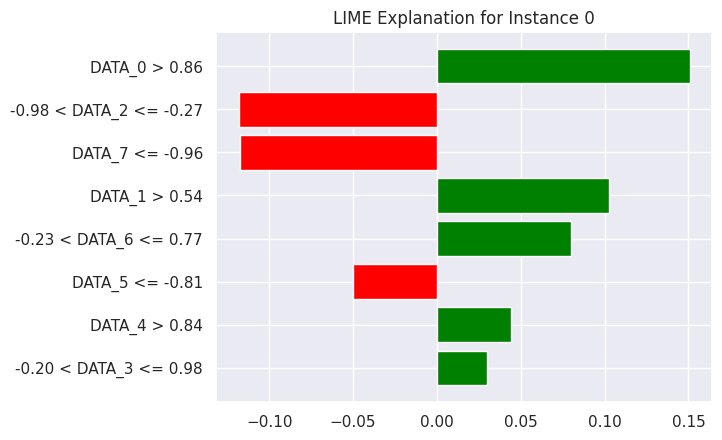

[0.15069532295591614, -0.1182092640572578, -0.11718545541667222, 0.10263808042391806, 0.08009780161405643, -0.049912071734044265, 0.044061641141500775, 0.029963748482444926]

 Shape of lime explanations:torch.Size([500, 8]),Shape of test data:torch.Size([500, 8])


In [48]:
feature_names = ["DATA_0", "DATA_1", "DATA_2", "DATA_3", "DATA_4", "DATA_5", "DATA_6", "DATA_7"]

#samples_to_train=1000
#samples_to_test=120
x_train = X_train_tensor[:samples_to_train].to(device)
x_test = X_test_tensor[:samples_to_test].to(device)
data_param_dict={}

if "LIME" not in data_param_dict:
    data_param_dict["LIME"] = {}

if "LIME" in data_param_dict:
    data_param_dict["LIME"]["inputs"]=x_test.detach().cpu().numpy()
else:
    data_param_dict["LIME"]["inputs"]=x_test.detach().cpu().numpy()

lime_importances,lime_exps=generate_lime_explanations(model, x_train, x_test, feature_names, num_samples=5000)
print(lime_importances[0])

print(f"\n Shape of lime explanations:{lime_exps.shape},Shape of test data:{x_test.shape}")

In [49]:
class LIMETabularExplainer(BaseExplainer):
    """LIME Explainer compatible with the framework's BaseExplainer"""

    def __init__(self, model, data: torch.FloatTensor, feature_names, **kwargs):
        super().__init__(model)
        self.data = data.cpu().numpy()
        self.feature_names = feature_names
        self.explainer = LimeTabularExplainer(
            self.data,
            feature_names=self.feature_names,
            class_names=['Normal', 'Attack'],
            discretize_continuous=True
        )
        self.kwargs = kwargs

    def get_explanations(self, inputs: torch.Tensor, label: torch.Tensor = None):
        lime_importances = []
        for sample in inputs.cpu().numpy():
            exp = self.explainer.explain_instance(
                sample,
                ann_predict,
                num_features=len(self.feature_names),
                **self.kwargs
            )
            lime_importances.append([exp.local_exp[1][i][1] for i in range(len(self.feature_names))])
        return torch.FloatTensor(lime_importances)

Generating LIME chart for instance [ 1.6657218   1.7361708  -0.36296618 -0.12645157  0.9640639  -1.369915
  0.48711216 -1.0745919 ]


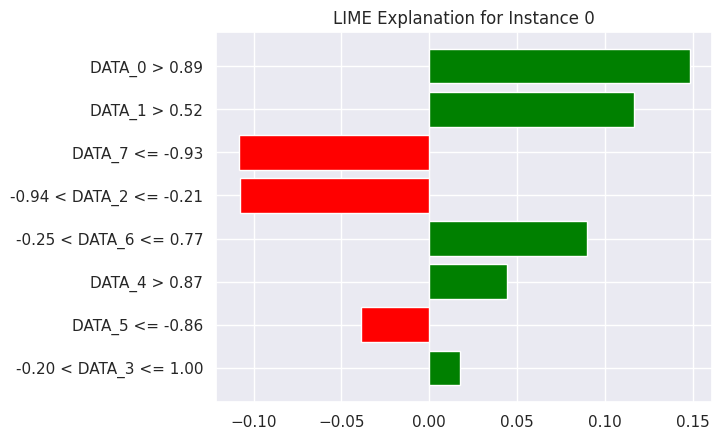

LIME Importances for first instance: [0.14829612413504076, 0.1164015368987034, -0.10845070029112275, -0.10786002523456154, 0.09008561748583485, 0.04416560484083049, -0.038702306742518976, 0.017553396874206893]

Shape of LIME explanations: torch.Size([100, 8]), Shape of test data: torch.Size([100, 8])


In [50]:
import torch
from lime.lime_tabular import LimeTabularExplainer

class LIMETabularExplainer:
    """
    LIME Explainer for Tabular Data (Binary Classification)

    :param model: Trained PyTorch model.
    :param x_train: Background dataset (torch.FloatTensor).
    :param feature_names: List of feature names.
    :param num_samples: Number of samples for LIME perturbations.
    """

    def __init__(self, model, x_train: torch.FloatTensor, feature_names: list, num_samples: int = 5000):
        self.model = model
        self.x_train = x_train.cpu().numpy()
        self.feature_names = feature_names
        self.num_samples = num_samples
        self.explainer = LimeTabularExplainer(
            self.x_train,
            feature_names=self.feature_names,
            class_names=['Normal', 'Attack'],
            discretize_continuous=True
        )

    def get_explanations(self, x_test: torch.FloatTensor, instance_idx: int = 0,label=1):
        """
        Computes LIME explanations for the given test data.

        :param x_test: torch.FloatTensor, input data samples to explain.
        :param instance_idx: Index of instance to visualize.
        :return: Tuple of (lime_importances, explanations tensor)
        """
        x_test_np = x_test.cpu().numpy()
        lime_importances = []
        attribution_scores = []

        for idx, sample in enumerate(x_test_np):
            exp = self.explainer.explain_instance(
                sample,
                ann_predict,
                num_features=len(self.feature_names),
                num_samples=self.num_samples,labels=(label,)
            )
            lime_importances.append([exp.local_exp[1][i][1] for i in range(len(self.feature_names))])
            attribution_scores.append(exp)

            # Generate visualization for first instance
            if idx == instance_idx:
                print(f"Generating LIME chart for instance {x_test[idx].cpu().numpy()}")
                fig = exp.as_pyplot_figure()
                plt.title(f"LIME Explanation for Instance {instance_idx}")
                plt.show()
                plt.close()

        return lime_importances, torch.FloatTensor(lime_importances)

# Initialize parameters
feature_names = ["DATA_0", "DATA_1", "DATA_2", "DATA_3",
                "DATA_4", "DATA_5", "DATA_6", "DATA_7"]

samples_to_train = 10000
samples_to_test = 100

# Prepare data
x_train = X_train_tensor[:samples_to_train].to(device)
x_test = X_test_tensor[:samples_to_test].to(device)

# Initialize LIME explainer and store in param dict
data_param_dict = {}

if "LIME" not in data_param_dict:
    data_param_dict["LIME"] = {}

# Create LIME explainer instance
lime_explainer = LIMETabularExplainer(
    model=model,
    x_train=x_train,
    feature_names=feature_names,
    num_samples=5000
)

# Store in param dict
data_param_dict["LIME"] = {
    "explainer": lime_explainer,
    "inputs": x_test.detach().cpu().numpy(),
    "feature_names": feature_names
}

# Generate explanations
lime_importances, lime_exps = lime_explainer.get_explanations(x_test)

print("LIME Importances for first instance:", lime_importances[0])
print(f"\nShape of LIME explanations: {lime_exps.shape}, Shape of test data: {x_test.shape}")

In [51]:
len(lime_importances)

100

In [52]:
''' import numpy as np
import matplotlib.pyplot as plt

# Convert to NumPy array for easier manipulation
lime_importances_np = np.array(lime_importances)

# Compute the mean importance across all test samples
mean_importances = np.mean(lime_importances_np, axis=0)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, mean_importances, color='skyblue')
plt.xlabel("Average Importance Score")
plt.ylabel("Features")
plt.title("LIME Feature Importances (Average Over Test Samples)")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()
 '''

' import numpy as np\nimport matplotlib.pyplot as plt\n\n# Convert to NumPy array for easier manipulation\nlime_importances_np = np.array(lime_importances)\n\n# Compute the mean importance across all test samples\nmean_importances = np.mean(lime_importances_np, axis=0)\n\n# Plot feature importance\nplt.figure(figsize=(10, 6))\nplt.barh(feature_names, mean_importances, color=\'skyblue\')\nplt.xlabel("Average Importance Score")\nplt.ylabel("Features")\nplt.title("LIME Feature Importances (Average Over Test Samples)")\nplt.gca().invert_yaxis()  # Invert y-axis for better readability\nplt.show()\n '

### III: Explanation method with default hyperparameters (IG)

In [53]:
# Choose explainer
method = 'ig'

inputs, labels = next(iter(testloader))
labels = labels.type(torch.int64)
outputs = model(inputs.to(device).float())  # Raw logits
preds = (torch.sigmoid(outputs) > 0.5).long()  # Convert to 0 or 1

labels = labels.type(torch.int64)
inputs, labels = next(iter(testloader))  # Gets only one batch (default batch_size=64)
print("Batch size of testloader",testloader.batch_size)  # Check batch size
print(len(labels))  # Output: 64

Batch size of testloader 64
64


Beyond just considering the accuracy of the classifier, there are many important questions to understand how the model is working and it's decision, which is the purpose of Captum, to help make neural networks in PyTorch more interpretable.

The first question we can ask is which of the features were actually important to the model to reach this decision? This is the first main component of Captum, the ability to obtain Feature Attributions. For this example, we will apply Integrated Gradients, which is one of the Feature Attribution methods included in Captum. More information regarding Integrated Gradients can be found in the original paper here: https://arxiv.org/pdf/1703.01365.pdf

To compute the integrated gradients, we use the attribute method of the IntegratedGradients object. The method takes tensor(s) of input examples (matching the forward function of the model), and returns the input attributions for the given examples. For a network with multiple outputs, a target index must also be provided, defining the index of the output for which gradients are computed. For this example, we provide target = 1, corresponding to survival.

The input tensor provided should require grad, so we call requires_grad_ on the tensor. The attribute method also takes a baseline, which is the starting point from which gradients are integrated. The default value is just the 0 tensor, which is a reasonable baseline / default for this task.

The returned values of the attribute method are the attributions, which match the size of the given inputs, and delta, which approximates the error between the approximated integral and true integral.

In [54]:
import torch
import numpy as np

def predictions(input_data):
    """
    Predicts binary class labels for a batch of input tensors using a neural network.

    Args:
    input_data (list of NumPy arrays): Input data to make predictions on.

    Returns:
    preds (NumPy array): Predicted class labels (0 or 1) for each input in the batch.
    """
    if not isinstance(input_data, torch.Tensor):
        print("Error: inputs is not a tensor! Converting to tensor now.")
            # Convert the list of NumPy arrays to a single NumPy array and create a tensor
        input_tensor = torch.tensor(np.array(input_data), dtype=torch.float32).to(device)
    else:
        input_tensor = input_data

    input_tensor = input_tensor.to(device)  # Move to GPU/CPU device
    # Ensure the model is in evaluation mode
    model.eval()

    with torch.no_grad():
        output = model(input_tensor)  # Forward pass
        preds = (torch.sigmoid(output) > 0.5).long()  # Convert probabilities to 0 or 1

    return preds  # Move back to CPU and convert to NumPy



### IV: Explanation method with additional hyperparameters (SHAP)

In [55]:
class SHAPExplainer(BaseExplainer):
    """SHAP Explainer compatible with the framework's BaseExplainer"""

    def __init__(self, model, data: torch.FloatTensor):
        super().__init__(model)
        self.model = model
        self.data = data
        self.explainer = shap.DeepExplainer(self.model, self.data)

    def get_explanations(self, inputs: torch.Tensor, label: torch.Tensor = None):
        path = f"/content/drive/MyDrive/car_hacking_results/SHAP_vs_LIME/shap_results"
        os.makedirs(path, exist_ok=True)
        shap_values = self.explainer.shap_values(inputs, check_additivity=False)
        feature_names=['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7']
        # Summary plot
        shap.summary_plot(shap_values.squeeze(), x_test.cpu().numpy(), show=False,feature_names=feature_names)

        # Save the summary plot in the specified path
        plt.savefig(os.path.join(path, f'shap_summary_{method_name}.png'), bbox_inches='tight')

        # Show the summary plot
        plt.show()  # This will display the plot in the output
        plt.close()  # Close the plot to free memory
        print(f'SHAP summary plot saved as {os.path.join(path, f"shap_summary_{method_name}.png")}')
        return torch.FloatTensor(shap_values.squeeze())


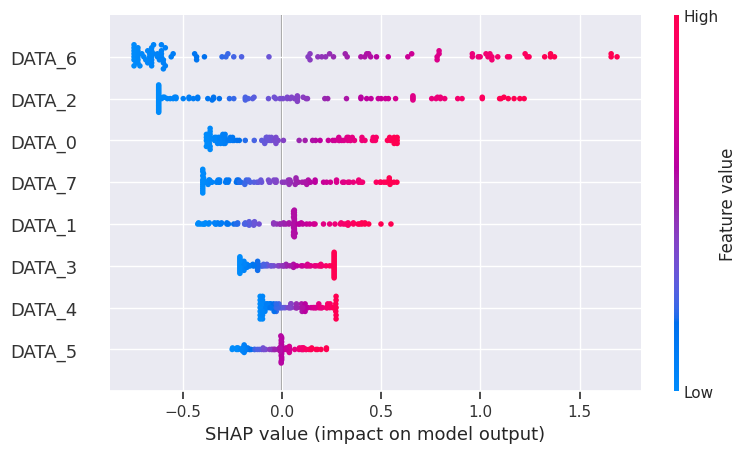

SHAP summary plot saved as /content/drive/MyDrive/car_hacking_results/SHAP_vs_LIME/shap_results/shap_summary_AFL1.png


In [56]:
x_train = X_train_tensor[:samples_to_train].to(device)
x_test = X_test_tensor[:samples_to_test].to(device)

# Use SHAPExplainer
explainer = SHAPExplainer(model, x_train)
shap_reshaped_values = explainer.get_explanations(x_test)

if "SHAP" not in data_param_dict:
    data_param_dict["SHAP"] = {}
data_param_dict["SHAP"]["inputs"] = x_test.detach().cpu().numpy()
data_param_dict["SHAP"]["explainer"] = explainer


In [57]:
print(shap_reshaped_values.shape),print(data_param_dict["SHAP"]["inputs"].shape)

torch.Size([100, 8])
(100, 8)


(None, None)

In [58]:
shap_exps=shap_reshaped_values.detach().cpu().numpy()
print(shap_exps[0])

[ 0.5456784   0.43624824 -0.18628885 -0.02176171  0.18433687 -0.20018727
  0.44597548 -0.31642106]


### (4) Choose an evaluation metric

In [59]:
from openxai.evaluator import ground_truth_metrics, prediction_metrics, stability_metrics
print('Ground truth metrics: ', ground_truth_metrics)
print('Prediction metrics: ', prediction_metrics)
print('Stability metrics: ', stability_metrics)

Ground truth metrics:  ['PRA', 'RC', 'FA', 'RA', 'SA', 'SRA']
Prediction metrics:  ['PGU', 'PGI']
Stability metrics:  ['RIS', 'RRS', 'ROS']


## metrics utils

In [60]:
import itertools
from scipy.stats import pearsonr, rankdata
from scipy.special import comb
from sklearn.metrics import auc
import pandas as pd
import numpy as np
import torch
import warnings; warnings.filterwarnings("ignore")
from tqdm import tqdm
from joblib import Parallel, delayed
import openxai.experiment_utils as utils

# ==== METRICS ==== #

# PRA
def pairwise_comp(explanations, ground_truth):
    """
    Compute rank agreement between all possible pairs
    of features in explanations and ground truth.

    :param explanations: np.array of shape (n_inputs, n_features)
    :param ground_truth: np.array of shape (n_features,)
    :return: pairwise_distr: np.array of shape (n_inputs,)
             mean_pairwise_distr: float
    """
    explanations, ground_truth = _preprocess_attributions(explanations, ground_truth)
    feat_pairs_w_same_rel_rankings = np.zeros(explanations.shape[0])

    # use rankdata instead of argsort to account for ties
    exp_ranks = rankdata(-np.abs(explanations), method='dense', axis=1)
    gt_rank = rankdata(-np.abs(ground_truth), method='dense')

    # count # of pairs of features with same relative ranking
    n_feat = explanations.shape[1]
    for feat1, feat2 in itertools.combinations_with_replacement(range(n_feat), 2):
        if feat1 != feat2:
            rel_rankingA = exp_ranks[:, feat1] < exp_ranks[:, feat2]
            rel_rankingB = gt_rank[feat1] < gt_rank[feat2]
            feat_pairs_w_same_rel_rankings += rel_rankingA == rel_rankingB
    pairwise_distr = feat_pairs_w_same_rel_rankings/comb(n_feat, 2)
    return pairwise_distr, np.mean(pairwise_distr)

# RC
def rankcorr(explanations, ground_truth):
    """
    Compute rank correlation between explanations and ground truth.

    :param explanations: np.array of shape (n_inputs, n_features)
    :param ground_truth: np.array of shape (n_features,)
    :return: corrs_distr: np.array of shape (n_inputs,)
             mean_corrs: float
    """
    explanations, ground_truth = _preprocess_attributions(explanations, ground_truth)
    corrs_distr = np.zeros(explanations.shape[0])
    exp_ranks = rankdata(-np.abs(explanations), method='dense', axis=1)
    gt_rank = rankdata(-np.abs(ground_truth), method='dense')
    for row in range(exp_ranks.shape[0]):
        corrs_distr[row], _ = pearsonr(exp_ranks[row], gt_rank)
    return corrs_distr, np.mean(corrs_distr)

# FA, RA, SA, SRA
def eval_ground_truth_faithfulness(explanations, ground_truth, predictions, k, metric, AUC=False):
    """
    Compute agreement fraction between top-k features of two explanations.

    :param explanations: np.array of shape (n_inputs, n_features)
    :param ground_truth: np.array of shape (n_features,)
    :param predictions: np.array of shape (n_inputs,), since we invert the ground truth depending on the prediction we are explaining
    :param k: int, number of top-k features
    :param metric: str, 'overlap', 'rank', 'sign', or 'ranksign'
    :param AUC: bool, whether to compute the AUC of the metric distribution
    :return: metric_distr: np.array of shape (n_inputs,)
             mean_metric: float
    """
    predictions = utils.convert_to_numpy(predictions)
    if explanations.shape[0] != len(predictions):
        raise ValueError('Number of predictions must match number of explanations.')
    explanations, ground_truth = _preprocess_attributions(explanations, ground_truth)
    n_inputs, n_features = explanations.shape
    ground_truths = (predictions*2-1)[:, None] * np.repeat(ground_truth.reshape(1, -1), len(predictions), axis=0)
    max_k = utils.convert_k_to_int(k, n_features)
    if AUC and max_k > 1:
        metric_distr_all_ks = np.array([_single_k_gt_faith(explanations, ground_truths, k, metric) for k in range(1, max_k + 1)])
        metric_distr = np.array([auc(np.arange(max_k)/(max_k-1), metric_distr_all_ks[:, i]) for i in range(n_inputs)])
    else:
        metric_distr = _single_k_gt_faith(explanations, ground_truths, max_k, metric)

    return metric_distr, np.mean(metric_distr)

import torch

import torch
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

def eval_relative_stability(explainer, inputs, model, perturb_method, feature_metadata, metric,
                            p_norm=2, n_samples=1000, n_perturbations=100, seed=-1, n_jobs=None, device=None):
    """
    Compute the relative stability of the explanations with respect to the input representations.
    Moves all inputs, model, and computations to the specified device.
    """
    # Determine the device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Using device: {device}")

    # Move model to the selected device
    model.to(device)

    # Convert inputs to tensor and move to device
    inputs = torch.tensor(inputs, dtype=torch.float32).to(device)

    metric = 'ROS' if (model.abbrv == 'lr') and (metric == 'RRS') else metric  # Adjust metric if needed

    params = [explainer, model, perturb_method, feature_metadata, metric, n_samples, n_perturbations, p_norm, seed]

    if n_jobs is not None:
        with utils.tqdm_joblib(tqdm(desc=f"Computing {metric}", total=len(inputs))) as progress_bar:
            stability_ratios = np.array(Parallel(n_jobs=n_jobs)(
                delayed(_single_idx_stability)(i, input.to(device), *params)  # Move each input to device
                for i, input in enumerate(inputs)))
    else:
        stability_ratios = np.array([
            _single_idx_stability(i, input.to(device), *params)  # Move input to device before passing
            for i, input in enumerate(tqdm(inputs))
        ])

    # Handle NaNs
    if np.isnan(stability_ratios).any():
        num_nans = np.sum(np.isnan(stability_ratios))
        print(f"{num_nans}/{len(stability_ratios)} NaNs in {metric} for {model.name}")
        stability_ratios = stability_ratios[~np.isnan(stability_ratios)]

    return stability_ratios, np.mean(stability_ratios)



# ==== HELPER FUNCTIONS ==== #

def _preprocess_attributions(explanations, ground_truth):
    """Convert to numpy and reshape (if necessary) for evaluation."""
    explanations, ground_truth = utils.convert_to_numpy(explanations), utils.convert_to_numpy(ground_truth)
    explanations = explanations.reshape(1, -1) if len(explanations.shape) == 1 else explanations
    return explanations, ground_truth

# eval_ground_truth_faithfulness
def _construct_topk_dfs(explanations, ground_truths, k, metric):
    """
    Construct dataframes for top-k features of explanations and ground truth.
    Each dataframe contains the top-k feature idxs and, if applicable,
    the ranks and signs of the top-k features (useful for debugging also).

    :param explanations: np.array of shape (n_inputs, n_features)
    :param ground_truths: np.array of shape (n_inputs, n_features,), since we invert the ground truth depending on the prediction we are explaining
    :param k: int, number of top-k features
    :param metric: str, 'overlap', 'rank', 'sign', or 'ranksign'
    :return: topk_idxs_dfs: size 2 list of pd.DataFrame of shape (n_inputs, k)
    """
    if metric not in ['overlap', 'rank', 'sign', 'ranksign']:
        raise NotImplementedError("Please make sure that have chosen one of the following metrics: {overlap, rank, sign, ranksign}.")
    attrs = [explanations, ground_truths]

    # Feature indices of top-k features (descending i.e. most important to least important)
    topk_idxs = [np.argsort(-np.abs(attr), axis=1)[:, :k] for attr in attrs]
    topk_idxs_dfs = [('feat' + pd.DataFrame(topk_idx).applymap(str)) for topk_idx in topk_idxs]
    if 'rank' in metric:  # RA, SRA
        all_feat_ranks = [rankdata(-np.abs(attr), method='dense', axis=1) for attr in attrs] # rankdata method used to support ties within topk
        topk_ranks = [np.take_along_axis(all_feat_rank, topk_idx, axis=1) for all_feat_rank, topk_idx in zip(all_feat_ranks, topk_idxs)]
        topk_idxs_dfs = [topk_idxs_df + ('rank' + pd.DataFrame(topk_rank).applymap(str)) for topk_idxs_df, topk_rank in zip(topk_idxs_dfs, topk_ranks)]
    if 'sign' in metric:  # SA, SRA
        topk_signs = [np.take_along_axis(np.sign(attr).astype(int), topk_idx, axis=1) for attr, topk_idx in zip(attrs, topk_idxs)]
        topk_idxs_dfs = [topk_idxs_df + ('sign' + pd.DataFrame(topk_sign).applymap(str)) for topk_idxs_df, topk_sign in zip(topk_idxs_dfs, topk_signs)]
    return topk_idxs_dfs

# eval_pred_faithfulness
def _get_perturbation_explanations(model, input, explainer,
                                   perturb_method, n_samples,
                                   feature_metadata, n_perturbations):
    y_pred = torch.argmax(model(input.float()), dim=1)[0]
    explanation = explainer.get_explanations(input.float(), label=y_pred)
    # Get perturbations of the input that have the same prediction
    x_prime_samples = perturb_method.get_perturbed_inputs(original_sample=input[0].float(),
                                                          feature_mask=torch.zeros(input.shape[-1], dtype=bool),
                                                          num_samples=n_samples,
                                                          feature_metadata=feature_metadata)
    y_prime_preds = torch.argmax(model(x_prime_samples.float()), dim=1)
    ind_same_class = (y_prime_preds == y_pred).nonzero()[: n_perturbations].squeeze()
    x_prime_samples = torch.index_select(input=x_prime_samples, dim=0, index=ind_same_class)
    y_prime_samples = torch.index_select(input=y_prime_preds, dim=0, index=ind_same_class)

    # For each perturbation, calculate the explanation
    exp_prime_samples = utils.convert_to_numpy(explainer.get_explanations(x_prime_samples, label=y_prime_samples))
    return x_prime_samples, exp_prime_samples, explanation

# eval_ground_truth_faithfulness
def _single_k_gt_faith(explanations, ground_truths, k, metric):
    """
    Evaluate ground truth faithfulness for a single k value and metric.
    :param explanations: np.array of shape (n_inputs, n_features)
    :param ground_truths: np.array of shape (n_inputs, n_features)
    :param k: int, number of top-k features
    :param metric: str, 'overlap', 'rank', 'sign', or 'ranksign'
    :return: metric_distr: np.array of shape (n_inputs,)
    """
    topk_idxs_df, topk_idxs_df_gt = _construct_topk_dfs(explanations, ground_truths, k, metric)
    if metric in ['overlap', 'sign']:  # FA, SA
        topk_sets = [set(list(row)) for row in topk_idxs_df.to_numpy()]
        topk_sets_gt = [set(list(row)) for row in topk_idxs_df_gt.to_numpy()]
        metric_distr = np.array([len(topk_set.intersection(topk_set_gt))/k\
                                 for topk_set, topk_set_gt in zip(topk_sets, topk_sets_gt)])
    elif metric in ['rank', 'ranksign']:  # RA, SRA
        metric_distr = (topk_idxs_df.to_numpy() == topk_idxs_df_gt.to_numpy()).sum(axis=1)/k
    return metric_distr

# eval_relative_stability
def _single_idx_stability(i, input, explainer, model, perturb_method, feature_metadata,
                      metric, n_samples, n_perturbations, p_norm, seed):
    """
    Inner loop computation extracted from eval_relative_stability to enable parallelization.
    """
    input = input.reshape(1, -1)
    torch.manual_seed(i if seed == -1 else seed); np.random.seed(i if seed == -1 else seed)
    x_prime_samples, exp_prime_samples, explanation = \
        _get_perturbation_explanations(model, input, explainer, perturb_method,
                                       n_samples, feature_metadata, n_perturbations)
    max_measure, valid_perturb = 0, False
    for x_prime, exp_prime in zip(x_prime_samples, exp_prime_samples):
        x_prime = x_prime.float().reshape(1, -1)
        if metric == 'RIS':
            input_repr, pert_repr = input, x_prime
        elif metric == 'RRS':
            input_repr = model.predict_layer(input, hidden_layer_idx=0, post_act=True)
            pert_repr = model.predict_layer(x_prime, hidden_layer_idx=0, post_act=True)
        elif metric == 'ROS':
            input_repr = model.predict_with_logits(input)
            pert_repr = model.predict_with_logits(x_prime)
        else:
            raise ValueError(f"The metric {metric} is not implemented in the current OpenXAI version.")
        repr_diff = utils.compute_Lp_norm_diff(input_repr, pert_repr, p_norm, normalize_to_relative_change=True)
        exp_diff = utils.compute_Lp_norm_diff(explanation, exp_prime, p_norm, normalize_to_relative_change=True)
        if np.isnan(repr_diff) or np.isnan(exp_diff) or repr_diff == 0:
            continue  # if stability measure is undefined, skip
        else:
            valid_perturb = True  # at least one perturbation with defined stability, else return np.nan
            stability_measure = np.divide(exp_diff, repr_diff)
            if stability_measure > max_measure:
                max_measure = stability_measure
    return max_measure if valid_perturb else np.nan


In [61]:

# PGI, PGU
def eval_pred_faithfulness(explanations, inputs, model, k, perturb_method, feature_metadata,
                           n_samples = 100, invert = False, seed=-1, n_jobs=None, AUC=False):
    """
    Approximates the expected absolute difference in predictions
    between the original instance and its perturbations on the (non) top-k features.

    :param explanations: torch.Tensor of shape (n_inputs, n_features)
    :param inputs: torch.Tensor of shape (n_inputs, n_features)
    :param model: torch.nn.Module
    :param k: int, number of top-k features
    :param perturb_method: PerturbMethod object
    :param feature_metadata: list of letters corresponding to feature types ('c' for continuous, 'd' for discrete)
    :param n_samples: int, number of perturbations
    :param invert: bool, whether to invert the top-k mask (True for PGU)
    :param seed: int, random seed (-1 to set the seed to the instance index)
    :param n_jobs: int, number of parallel jobs, -1 to use all available cores, None to disable parallelism
    :param AUC: bool, whether to compute the AUC of the metric distribution
    :return: float
    """
    # Preprocess
    explanations, inputs = utils.convert_to_tensor(explanations), utils.convert_to_tensor(inputs)
    if inputs.shape != explanations.shape:
        raise ValueError("The input and explanation shapes do not match.")
    n_inputs, n_features = explanations.shape
    max_k = utils.convert_k_to_int(k, n_features)

    # Compute metric
    params = [inputs, explanations, invert, n_jobs, [model, perturb_method, feature_metadata, n_samples, seed]]

    if AUC and max_k > 1:
        metric_distr_all_ks = np.array([_single_k_pred_faith(k, *params) for k in range(1, max_k + 1)])
        metric_distr = np.array([auc(np.arange(max_k)/(max_k-1), metric_distr_all_ks[:, i]) for i in range(n_inputs)])
    else:
        metric_distr = _single_k_pred_faith(max_k, *params)

    return metric_distr, np.mean(metric_distr)

## OPENXAI Results

In [62]:
# List of explainers and metrics
explainers = {
    'LIME': lime_exps,
    'SHAP': shap_reshaped_values,
    #'IntegratedGradients': ig_exps,
    #"grad":grad_exps
}

In [63]:
data_param_dict.keys()

dict_keys(['LIME', 'SHAP'])

In [64]:
metrics_dict = {
    'PRA': pairwise_comp,
    'RC': rankcorr,
    'FA': eval_ground_truth_faithfulness,
    'RA': eval_ground_truth_faithfulness,
    'SA': eval_ground_truth_faithfulness,
    'SRA': eval_ground_truth_faithfulness,
    'PGU': eval_pred_faithfulness,
    'PGI': eval_pred_faithfulness,
    'RIS': eval_relative_stability,
    'RRS': eval_relative_stability,
    'ROS': eval_relative_stability
}

metrics_params = {
    'PRA': {},
    'RC': {},
    'FA': {'metric': 'overlap'},
    'RA': {'metric': 'rank'},
    'SA': {'metric': 'sign'},
    'SRA': {'metric': 'ranksign'},
    'PGU': {'invert': True},
    'PGI': {'invert': False},
    'RIS': {'metric': 'RIS'},
    'RRS': {'metric': 'RRS'},
    'ROS': {'metric': 'ROS'}
}


# Function to evaluate a metric
def evaluate_metric(model, metric, param_dict):
    if metric not in metrics_dict:
        raise ValueError(f"Metric {metric} is not supported.")
    print("Inside evaluate_metric, param_dict keys:", param_dict.keys())

    metric_function = metrics_dict[metric]  # Get the function dynamically
    param_dict.update(metrics_params[metric])  # Merge parameters

    # Ensure model and inputs are on the correct device
    param_dict['model'] = model.to(device)
    param_dict = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in param_dict.items()}

    return metric_function(**param_dict)


def _single_k_pred_faith(k, inputs, explanations, invert, n_jobs, params):
    """Process inputs with device verification"""
    print(f"\n[_single_k_pred_faith] Inputs device: {inputs.device}")
    print(f"[_single_k_pred_faith] Explanations device: {explanations.device}")
    print(f"_single_k_pred_faith called with k={k}")
    k=int(3)
    model = params[0]
    print(f"[_single_k_pred_faith] Model device in params: {next(model.parameters()).device}")

    if n_jobs is not None:
        with utils.tqdm_joblib(tqdm(desc=f"Computing {'PGU' if invert else 'PGI'}", total=len(inputs))) as progress_bar:
            #return Parallel(n_jobs=n_jobs)(delayed(_single_idx_pred_faith)(i, input, explanation, k, invert, *params))
            return Parallel(n_jobs=n_jobs)(
    delayed(_single_idx_pred_faith)(i, inp, exp, k, invert, *params)
    for i, (inp, exp) in enumerate(zip(inputs, explanations))
)

    else:
        return np.array([
            _single_idx_pred_faith(i, input, explanation, k, invert, *params)
            for i, (input, explanation) in enumerate(tqdm(zip(inputs, explanations)))
        ])



def _single_idx_pred_faith(i, input, explanation, k, invert,
                          model, perturb_method, feature_metadata,
                          n_samples, seed):
    """Core computation with detailed device checks"""
    # Device verification
    model_device = next(model.parameters()).device
    print(f"\n[_single_idx_pred_faith {i}] Input device: {input.device}")
    print(f"[_single_idx_pred_faith {i}] Explanation device: {explanation.device}")
    print(f"[_single_idx_pred_faith {i}] Model device: {model_device}")

    # Generate mask
    top_k_mask = utils.generate_mask(explanation, k).to(model_device)
    top_k_mask = torch.logical_not(top_k_mask) if invert else top_k_mask
    print(f"[_single_idx_pred_faith {i}] Mask device: {top_k_mask.device}")

    # Generate perturbations
    torch.manual_seed(i if seed == -1 else seed)
    np.random.seed(i if seed == -1 else seed)
    x_perturbed = perturb_method.get_perturbed_inputs(
        original_sample=input.to(model_device),
        feature_mask=top_k_mask,
        num_samples=n_samples,
        feature_metadata=feature_metadata
    ).to(model_device)

    print(f"[_single_idx_pred_faith {i}] Perturbed inputs device: {x_perturbed.device}")

    # Compute predictions
    with torch.no_grad():
        y = model(input.reshape(1, -1).float().to(model_device))
        y_perturbed = model(x_perturbed.float())

    print(f"[_single_idx_pred_faith {i}] Predictions device: {y.device}, {y_perturbed.device}")

    return torch.mean(torch.abs(y_perturbed - y)).item()

### Prediction_metrics

In [65]:
metrics_list = ['PGU', 'PGI']#, 'FA', 'RA', 'SA', 'SRA']

# Dictionary to store results
results = {}

# Evaluate each explainer with all metrics
for explainer_name, explanations in explainers.items():
    results[explainer_name] = {}

    # Load config and prepare parameters
    param_dict = load_config('/content/drive/MyDrive/OpenXAI-main/OpenXAI-main/experiment_config.json')['evaluators']['prediction_metrics']
    #param_dict['inputs'] = x_test.to(device)

    # Convert inputs if necessary
    inputs = data_param_dict[explainer_name]['inputs']
    if not isinstance(inputs, torch.Tensor):
        inputs = torch.tensor(inputs, dtype=torch.float32)
    inputs = inputs.to(device)  # Move to device after conversion
    param_dict['inputs'] = inputs

    if not isinstance(explanations, torch.Tensor):
        explanations = torch.tensor(explanations, dtype=torch.float32)

    param_dict['explanations'] = explanations.to(device)
    param_dict['feature_metadata'] = ['c'] * 8
    param_dict['perturb_method'] = get_perturb_method(param_dict['std'])
    del param_dict['std']

    for metric in metrics_list:
        print(f"Evaluating {explainer_name} with {metric}...")

        # Evaluate and store results
        score, mean_score = evaluate_metric(model, metric, param_dict)
        std_err = np.std(score) / np.sqrt(len(score))

        # Store the results
        results[explainer_name][metric] = {
            #'score': score,
            'mean_score': mean_score,
            'std_error': std_err,
            "score":f"{mean_score:.2f}\u00B1{std_err:.2f}"
        }

Evaluating LIME with PGU...
Inside evaluate_metric, param_dict keys: dict_keys(['k', 'AUC', 'n_samples', 'seed', 'n_jobs', 'inputs', 'explanations', 'feature_metadata', 'perturb_method'])

[_single_k_pred_faith] Inputs device: cuda:0
[_single_k_pred_faith] Explanations device: cuda:0
_single_k_pred_faith called with k=1
[_single_k_pred_faith] Model device in params: cuda:0

[_single_k_pred_faith] Inputs device: cuda:0
[_single_k_pred_faith] Explanations device: cuda:0
_single_k_pred_faith called with k=2
[_single_k_pred_faith] Model device in params: cuda:0
Evaluating LIME with PGI...
Inside evaluate_metric, param_dict keys: dict_keys(['k', 'AUC', 'n_samples', 'seed', 'n_jobs', 'inputs', 'explanations', 'feature_metadata', 'perturb_method', 'invert', 'model'])

[_single_k_pred_faith] Inputs device: cuda:0
[_single_k_pred_faith] Explanations device: cuda:0
_single_k_pred_faith called with k=1
[_single_k_pred_faith] Model device in params: cuda:0

[_single_k_pred_faith] Inputs device: cu

In [66]:
results

{'LIME': {'PGU': {'mean_score': 0.0704293604940176,
   'std_error': 0.0024272357608915297,
   'score': '0.07±0.00'},
  'PGI': {'mean_score': 0.05659008080139756,
   'std_error': 0.001999926083432806,
   'score': '0.06±0.00'}},
 'SHAP': {'PGU': {'mean_score': 0.04720116205513478,
   'std_error': 0.002072050478243251,
   'score': '0.05±0.00'},
  'PGI': {'mean_score': 0.07577163670212031,
   'std_error': 0.0028064731972356266,
   'score': '0.08±0.00'}}}

In [67]:
import json

custom_path = os.path.join(path, "OPEN_XAI_explanation_metrics_results.json")

# Save as JSON
with open(custom_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Results saved at: {custom_path}")


Results saved at: /content/drive/MyDrive/AFL1/lime_vs_shap_comparison_results/OPEN_XAI_explanation_metrics_results.json


In [68]:
# Convert dictionary into a structured DataFrame
df1 = pd.DataFrame({
    "Metric": ["PGU", "PGI"],
    "SHAP Score": [results["SHAP"]["PGU"]["score"], results["SHAP"]["PGI"]["score"]],
    "LIME Score": [results["LIME"]["PGU"]["score"], results["LIME"]["PGI"]["score"]]
})

custom_path = os.path.join(path, "OPEN_XAI_explanation_metrics.csv")

# Save the DataFrame as a CSV file
df1.to_csv(custom_path, index=False)

# Display confirmation message
print(f"File saved successfully at: {custom_path}")

File saved successfully at: /content/drive/MyDrive/AFL1/lime_vs_shap_comparison_results/OPEN_XAI_explanation_metrics.csv


In [69]:
df1

,Metric,SHAP Score,LIME Score
0,PGU,0.05±0.00,0.07±0.00
1,PGI,0.08±0.00,0.06±0.00


# All Metrics

In [70]:
#Quantus Metrics
df

,Metric,SHAP,LIME
0,MPRT,0.529,1.000
1,Complexity,1.728,1.760
2,Effective Complexity,8.000,8.000
3,Sparseness,0.431,0.417


In [71]:
#OPENXAI METRICS
df1

,Metric,SHAP Score,LIME Score
0,PGU,0.05±0.00,0.07±0.00
1,PGI,0.08±0.00,0.06±0.00
